In [ ]:
# ==================================================================================================
# ------------------------ !!! NOTE ON GUROBI LICENSE - READ BEFORE TO RUN !!! ---------------------
# ==================================================================================================
# Within "ATO_model" function, follow the instruction based on your license


# =================================================
# ------ NOTE ON COMPUTATIONAL TIME REQUIRED ------
# =================================================
# It is suggested to look at the Notebook for results, because the code may take several time, depending on the PC specs. 
# Clearly, the results will be exactly the same. If you want to run, just push the Run bottom of your IDE

# ====================================================================================================

In [6]:
# REQUIREMENTS

# Math and Statistics
import numpy as np
from scipy.stats import norm

#Optimization
import gurobipy as gp
from gurobipy import GRB

# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns


# Optim Functions

In [ ]:
# =================================================
# ================ OPTIM FUNCTIONS ================
# =================================================

def generate_logNorm_scenarios(n_scenarios:int, n_products:int, mean:np.ndarray, var: np.ndarray, rng: np.random.Generator) ->np.ndarray:
    """
    Generates a matrix of log-normal demand scenarios based on target mean and variance.

    Args:
        n_scenarios (int): number of scenario
        n_products (int): number of end products
        mean (np.ndarray): average demand of each product
        var (np.ndarray): variance of demand for each product
        rng (np.random.Generator): reproducibility

    Returns:
        np.ndarray: matrix of scenario, shape(n_scenarios, n_products)
    """

    # LogNormal parameters (mean and standard deviation of the underlying normal distribution)

    scale_param = np.sqrt(np.log((var / (mean**2)) + 1.0)) #std of Normal
    loc_param = np.log(mean) - (scale_param**2 / 2.0) # mean of Normal

    # Generate scenarios
    scenarios_matrix = rng.lognormal(
        mean=loc_param,
        sigma=scale_param,
        size=(n_scenarios, n_products)
    )
    return scenarios_matrix


def ATO_model(I:int, J:int, M: int, C: np.ndarray, P:np.ndarray, L:np.ndarray, T:np.ndarray, G:np.ndarray, scenarios_matrix: np.ndarray, verbose=False) -> tuple:
    """
    Optimizes the two-stage stochastic Assemble-to-Order (ATO) problem.

    Args:
        I (int): Number of components
        J (int): Number of end products
        M (int): Number of machines
        C (np.ndarray): Cost array for producing components (Size: I)
        P (np.ndarray): Price/Revenue array for selling end products (Size: J).
        L (np.ndarray): Capacity limits for each machine (Size: M).
        T (np.ndarray): Time required to produce components on machines (Size: I x M).
        G (np.ndarray): Gozinto matrix mapping components to products (Size: I x J).
        scenarios_matrix (np.ndarray): Sampled demand scenarios (Size: num_scenarios x J).
        verbose (bool, optional): If True, prints Gurobi solver output. Defaults to False.

    Returns:
        tuple: (Optimal Expected Profit (float), Optimal Stage 1 Decisions x* (np.ndarray))
    """
    # ============= Set up environment =============
    # NOTE: If you use a local gurobi.lic file, replace this entire options 
    # block with a simple `env = gp.Env()`. 
    # Otherwise, insert your WLS credentials below.
    
    options = {
        "WLSACCESSID": "YOUR_REAL_ID_HERE", 
        "WLSSECRET": "YOUR_REAL_SECRET_HERE",
        "LICENSEID": 1234567, # Replace with your real ID
    }

    if not verbose:
        options["OutputFlag"] = 0
        
    env = gp.Env(params=options)
    # ==============================================


    # ============= Create the model
    # Retrieve num_scenarios
    num_scenarios = scenarios_matrix.shape[0]
    m = gp.Model("ATO", env=env)

    # ============= Create variables
    # --- Here-and-now (stage 1)
    x = m.addVars(             
        I,
        vtype=GRB.CONTINUOUS,
        name="x"
    ) 
    # --- Wait-and-see (stage 2)
    y = m.addVars(              
        J,
        num_scenarios, #i.e. num_scenarios
        vtype=GRB.CONTINUOUS,
        name="y"
    )

    # ============= Objective function (setting: maximize expected profit)
    costs = gp.quicksum(C[i]*x[i] for i in range(I)) # Costs. \sum_{i \in I}{C_i \cdot x_i}, total costs constraint
    p_scenario = 1/num_scenarios # Scenario probability. Considered every scenario with the same probability 
    exp_revenue = p_scenario * gp.quicksum(P[j]*y[j, scenario] for j in range(J) for scenario in range(num_scenarios)) # Revenues. \sum_{s \in S}\pi^s \cdot \sum_{j \in J} P_j y_j^s
    m.setObjective(
        - costs + exp_revenue,
        sense=GRB.MAXIMIZE
    )

    # ============= Constraints
    # --- Time Constrain (Machine & Component related)
    for machine in range(M): # Iterate over machines
        m.addConstr(
            gp.quicksum(T[i,machine]* x[i] for i in range(I)) <= L[machine], # \sum_{i \in I} T_{im}x_i \leq L_m
            name=f"TimeConstrain_Machine_{machine}"
        )

    # --- Demand Constrain & Components Quantity Constrain :
    for scenario in range(num_scenarios):
        for j in range(J):
            # Demand
            m.addConstr(
                y[j, scenario] <= scenarios_matrix[scenario, j], # NOTE on indexing: scenarios_matrix has shape (num_scenarios, product), therefore each row represent a demand scenario
                name=f"DemandConstrain_j{j}_s{scenario}"
            )

        # Components Quantity: num of componentes available less or equal than produced at stage 1
        for i in range(I):
            m.addConstr(
                gp.quicksum(G[i, j]*y[j, scenario] for j in range(J)) <= x[i], #\sum_{j\in J} G_{ij}y_j^s \leq x_i
                name=f"GozintoConstrain_i{i}_s{scenario}"
            )
        
    # --- Non - negativity Constraint for x and y: default lb=0.0, no need to specify it

    # ============= Perform Optimization
    m.optimize()

    if m.status == GRB.OPTIMAL:
        opt_x = np.array([x[i].X for i in range(I)])
        return m.ObjVal, opt_x
    else:
        print("Optimization failed. Status code:", m.status)
        return None, None


def in_sample_stability(N_pairs:int, cardinality_scenarios: np.ndarray, SEED:int, I:int, J:int, M: int, C: np.ndarray, 
                            P:np.ndarray, L:np.ndarray, T:np.ndarray, G:np.ndarray, mean:np.ndarray, var:np.ndarray, confidence_level: float=0.95) -> tuple:
    """
    Evaluates the In-Sample stability. In order to realize useful plots, the whole history of results is tested.

    Args:
        N_pairs (int): Number of scenario pairs (M) to generate per cardinality.
        cardinality_scenarios (np.ndarray): List of scenario sizes (N) to test.
        SEED (int): Base random seed for reproducibility.
        I, J, M, C, P, L, T, G: Parameters defining the ATO model constraints.
        mean (np.ndarray): Log-normal mean parameters for demand generation.
        var (np.ndarray): Log-normal variance parameters for demand generation.
        confidence_level (float): Target confidence level (e.g., 0.95 for 95% CI).

    Returns:
        tuple: (first_nstable: first scenario size for which the stopping conditions is triggered, results: useful metrics for plots)
    """
    # Store results
    results_IS = []
    first_nstable = None 

    # Iterate over the cardinality of scenario sets
    for n in cardinality_scenarios:
        # Store results
        phi = []
        
        # Iterate over the number of "sets of scenarios" (S, S') 
        for i in range(N_pairs):
            # Update generator
            rng_S = np.random.default_rng(SEED + i)
            rng_Sprime = np.random.default_rng(SEED + N_pairs + i)

            # Generate pair of sets (S_i, S_i')
            scenarios_S = generate_logNorm_scenarios(n_scenarios=n, n_products=J, mean=mean, var=var, rng=rng_S) #generate scenarios matrix "S"
            scenarios_Sprime = generate_logNorm_scenarios(n_scenarios=n, n_products=J, mean=mean, var=var, rng=rng_Sprime) #generate another scenarios matrix " S' " with different SEED

            # Compute objective function considering both scenarios
            obj_S, _ = ATO_model(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, scenarios_matrix=scenarios_S, verbose=False)
            obj_Sprime, _ = ATO_model(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, scenarios_matrix=scenarios_Sprime, verbose=False)
            phi_i =  obj_S - obj_Sprime
            phi.append(phi_i)


        # Check Condition
        phi_sample = 1/N_pairs*np.sum(phi)
        std_sample = np.std(phi, ddof=1)

        alpha = 1 - confidence_level
        z = norm.ppf(1-alpha/2)

        ci_lower = phi_sample - z * std_sample / np.sqrt(N_pairs)
        ci_upper = phi_sample + z * std_sample / np.sqrt(N_pairs)
        ci_width = ci_upper - ci_lower

        # Store results for plot
        results_IS.append({
            "n": n,
            "phi_mean": phi_sample,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "ci_width": ci_width
        })

        # Check whether 0 is within CI or not
        if ci_lower <= 0 <= ci_upper and first_nstable is None:
            first_nstable = n
            print(f"In-Sample Stability reached at N: {n}")

    if first_nstable is None:
        print("Stability not reached within the provided cardinality sets.")

    return first_nstable, results_IS


def ysOnly_ATO_model_(x_star: np.ndarray, E_big_scenarios_matrix: np.ndarray, I: int, J: int, C: np.ndarray, P: np.ndarray, G: np.ndarray, verbose=False) -> float:
    """
    Only optimize second-stage variables, receiving first stage as input.

    Args:
        x_star (np.ndarray): The fixed Stage 1 component production decisions.
        E_big_scenarios_matrix (np.ndarray): The massive Out-of-Sample demand matrix.
        I, J, C, P, G: Parameters defining the ATO model costs and Gozinto structure.
        verbose (bool): If True, prints Gurobi solver output. Defaults to False.

    Returns:
        float: The "true" expected profit of the fixed x* decisions over matrix E.
    """
    # LICENSE (replace with the actual ones)
    options = {
        "WLSACCESSID": "8d346a9e-02c4-4f40-b608-0257caff602f",
        "WLSSECRET": "f1c8d187-713e-47ed-ab66-093325b193b4",
        "LICENSEID": 2834817, 
    }

   # ============= Set up environment =============
    # NOTE: If you use a local gurobi.lic file, replace this entire options 
    # block with a simple `env = gp.Env()`. 
    # Otherwise, insert your WLS credentials below.
    
    options = {
        "WLSACCESSID": "YOUR_REAL_ID_HERE", 
        "WLSSECRET": "YOUR_REAL_SECRET_HERE",
        "LICENSEID": 1234567, # Replace with your real ID
    }

    if not verbose:
        options["OutputFlag"] = 0
        
    env = gp.Env(params=options)
    # ==============================================


    # ============= Create the model
    # Retrieve num_scenarios
    E_num_scenarios = E_big_scenarios_matrix.shape[0]
    m = gp.Model("ATO_ys", env=env)

    # ============= Create variables
    # --- Wait-and-see (stage 2)
    y = m.addVars(              
        J,
        E_num_scenarios, #i.e. num_scenarios
        vtype=GRB.CONTINUOUS,
        name="y"
    )

    # ============= Objective function
    p_scenario = 1.0 / E_num_scenarios
    exp_revenue = p_scenario * gp.quicksum(P[j] * y[j, s] for j in range(J) for s in range(E_num_scenarios))
    m.setObjective(exp_revenue, sense=GRB.MAXIMIZE)

    # ============= Constraints 
    for s in range(E_num_scenarios):
        for j in range(J):
            # Demand constraint
            m.addConstr(y[j, s] <= E_big_scenarios_matrix[s, j], name=f"Demand_j{j}_s{s}")
            
        for i in range(I):
            # Gozinto constraint 
            m.addConstr(gp.quicksum(G[i, j] * y[j, s] for j in range(J)) <= x_star[i], name=f"Gozinto_i{i}_s{s}")

    # Perform Optimization
    m.optimize()
    
    if m.status == GRB.OPTIMAL:
        # Subtract the deterministic sunk cost of Stage 1
        stage_1_cost = np.sum(C * x_star)
        true_profit = m.ObjVal - stage_1_cost
        return true_profit
    else:
        print("Evaluation failed. Status code:", m.status)
        return None


def out_of_sample_stability(S_cardinality: np.ndarray, N_runs: int, I: int, J: int, M: int, C: np.ndarray, 
                                P: np.ndarray, L: np.ndarray, T: np.ndarray, G: np.ndarray, n_products: int, mean: np.ndarray, var: np.ndarray, 
                                SEED: int, E_num_scenarios: int=10_000, tol: float=1e-2) -> tuple:
    """
    Out-of-Sample stability.

    Args:
        S_cardinality (np.ndarray): List of scenario sizes (N) to test.
        N_runs (int): Number of independent SAA runs to average per cardinality.
        I, J, M, C, P, L, T, G: Parameters defining the ATO model.
        n_products (int): Number of end products (J) for scenario generation.
        mean (np.ndarray): Log-normal mean parameters for demand generation.
        var (np.ndarray): Log-normal variance parameters for demand generation.
        SEED (int): Base random seed for reproducibility.
        E_num_scenarios (int): Size of the massive "True Future" matrix E.
        tol (float): Acceptable optimality gap tolerance (expressed as a Percentage). Deafult to 0.01 (1%). 

    Returns:
        tuple: (first_stable_N, tested_N, discrepancy_history, q05_history, q95_history, obj_S_history, obj_E_history)

    """
    # Generate OOS scenarios
    rng_E = np.random.default_rng(SEED + 9999)
    E_big_scenarios_matrix = generate_logNorm_scenarios(n_scenarios=E_num_scenarios, n_products=n_products, mean=mean, var=var, rng=rng_E)

    # Store the gap between obj functions for plots
    results_OS = []
    first_nstable = None

    # Compute Objective Function discrepancy
    for s in S_cardinality:
        discrepancy = []
        obj_S_runs = []
        obj_E_runs = []

        for n in range(N_runs):
            # Reproducibility
            rng_S = np.random.default_rng(SEED + n + int(s)*1000)

            # Generate scenarios "S" with regular dimension
            S_scenarios_matrix = generate_logNorm_scenarios(n_scenarios=s, n_products=n_products, mean=mean, var=var, rng=rng_S)

            # Retrieve First Stage decision variables x^* and Objective Function value
            obj_func_S, x_star =  ATO_model(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, scenarios_matrix=S_scenarios_matrix, verbose=False)
            
            # Compute obj function for "E" considering x^* as input
            obj_func_E = ysOnly_ATO_model_(x_star=x_star, E_big_scenarios_matrix=E_big_scenarios_matrix, I=I, J=J, C=C, P=P, G=G, verbose=False)
        
            # Compute relative discrepancy and Store it
            discr_i = np.abs(obj_func_S - obj_func_E)/np.abs(obj_func_E)
            discrepancy.append(discr_i)

            obj_S_runs.append(obj_func_S)
            obj_E_runs.append(obj_func_E)

    
        avg_discrepancy = np.mean(discrepancy)
        q_05 = np.quantile(discrepancy, 0.05)
        q_95 = np.quantile(discrepancy, 0.95)

        # Append data
        results_OS.append({
            "n":        s,
            "mean_gap": avg_discrepancy,
            "q05_gap":  q_05,
            "q95_gap":  q_95,
            "obj_S":    np.mean(obj_S_runs),
            "obj_E":    np.mean(obj_E_runs)
        })

        # Stopping Condition: f(x^*|S) \approx f(x^* | E)
        if avg_discrepancy <= tol and first_nstable is None:
            first_nstable = s
            print(f"Out-of-Sample Stability reached at N = {s}")

    if first_nstable is None:
        print("OOS stability not reached: change the tolerance or the scenarios cardinality")

    return first_nstable, results_OS


def compute_VSS_EVPI_metrics(I: int, J: int, M: int, C: np.ndarray, P: np.ndarray, L: np.ndarray, T: np.ndarray, 
                                G: np.ndarray, mean: np.ndarray, var: np.ndarray, SEED: int, N_stable: int = 1024) -> tuple:
    """
    Computes the Expected Value of Perfect Information (EVPI) and 
    the Value of the Stochastic Solution (VSS).

    Args:
        I, J, M, C, P, L, T, G: Parameters defining the ATO model.
        mean, var (np.ndarray): Demand distribution parameters.
        SEED (int): For reproducibility.
        N_stable (int): Size of the scenario matrix used for evaluation. Default to the N chosen during IN and OUT stability analysis

    Returns:
        tuple: (WS_obj, RP_obj, RP_x, EEV_obj, EVPI, VSS)
    """
    # Generate scenario matrix with stable N
    rng = np.random.default_rng(SEED + 999)
    scenarios_matrix = generate_logNorm_scenarios(n_scenarios=N_stable, n_products=J, mean=mean, var=var, rng=rng)

    # ===== Evaluate RP (Recourse problem)
    RP_obj, RP_x = ATO_model(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, scenarios_matrix=scenarios_matrix, verbose=False)

    # ===== Evaluate WS (Wait-and-see)
    ws_values = []
    for s in range(N_stable):
        # Extract single scenario while maintaining 2D shape (1, J)
        single_scenario = scenarios_matrix[s:s+1, :] 
        ws_s, _ = ATO_model(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, scenarios_matrix=single_scenario, verbose=False)
        ws_values.append(ws_s)
    
    WS_obj = np.mean(ws_values)

    # ===== Evaluate Expected Value Solution (EEV)
    mean_scenario = np.array([mean]) # Adjust the shape according to what ATO_model function requires
    _, EV_x = ATO_model(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, scenarios_matrix=mean_scenario, verbose=False)
    # Compute EEV
    EEV_obj = ysOnly_ATO_model_(x_star=EV_x, E_big_scenarios_matrix=scenarios_matrix, I=I, J=J, C=C, P=P, G=G, verbose=False)

    # ===== Compute EVPI and VSS (maximization signs)
    EVPI = WS_obj - RP_obj
    VSS = RP_obj - EEV_obj

    print(f"\n--- Stochastic Metrics Evaluation (N={N_stable}) ---")
    print(f"Wait-and-See (WS):                €{WS_obj:>10,.2f}")
    print(f"Recourse Problem (RP):            €{RP_obj:>10,.2f}")
    print(f"Exp. Result of Exp. Value (EEV):  €{EEV_obj:>10,.2f}")
    print("-" * 46)
    print(f"EVPI (WS - RP):                   €{EVPI:>10,.2f}")
    print(f"VSS  (RP - EEV):                  €{VSS:>10,.2f}")
    print("-" * 46)
    
    return WS_obj, RP_obj, RP_x, EEV_obj, EVPI, VSS


def robustness_parameter_perturbation(x_star: np.ndarray, mean: np.ndarray, var: np.ndarray,
                                            RP_obj: float, I: int, J: int, C: np.ndarray, P: np.ndarray, G: np.ndarray,
                                            deltas: np.ndarray, SEED: int, N_eval: int = 5000) -> dict:
    """
    Simulate the situation where an estimation error on mean or variance has been done.
    Parameters mu and sigma^2 are increased/decreased by a percentage wrt the initial forecasted value.

    Perturbations are independent in order to isolate the effects and to understand what hurts the most.
      - mu sweep: perturb mean only, var held at nominal
      - sigma sweep: perturb var only, mean held at nominal

    Args:
        x_star (np.ndarray): first-stage solution (from RP at N=N_stable).
        mean, var (np.ndarray): nominal (assumed) demand parameters.
        RP_obj (float): expected profit (from RP at N=N_stable).
        I, J, C, P, G: ATO model parameters.
        deltas (np.ndarray): perturbation levels, e.g. [-0.3, -0.2, ..., 0.3].
        SEED (int): for reproducibility.
        N_eval (int): scenario count for evaluating the "true" distribution.

    Returns:
        dict: {"delta": deltas, "mu_profitvar": [...], "mu_profitvar_pct": [...], "sigma_profitvar": [...], "sigma_profitvar_pct": [...]}
    """
    # Store results

    #percentages variations
    profit_rel_variation_mu = []
    profit_rel_variation_var = []

    #absolute variations
    profit_variation_mu = []
    profit_variation_var = []


    for k, delta in enumerate(deltas):
        # === perturb mean, keep var  
        rng_mu = np.random.default_rng(SEED + 5000 + k)
        true_mean_mu = mean * (1 + delta)
        scen_mu = generate_logNorm_scenarios(N_eval, J, true_mean_mu, var, rng_mu) # Generate scenarios with the new perturbed parameters
        profit_mu = ysOnly_ATO_model_(x_star, scen_mu, I, J, C, P, G, verbose=False) # Optimize second-stage variables and obtain the Expected profit
        # Store the results
        profit_rel_variation_mu.append(100 * (profit_mu - RP_obj) / RP_obj) 
        profit_variation_mu.append(profit_mu - RP_obj)

        # === perturb var, keep mean 
        rng_sigma = np.random.default_rng(SEED + 9000 + k)
        true_var_sigma = var * (1 + delta)
        true_var_sigma = np.clip(true_var_sigma, 1e-6, None) # Avoid negative var
        scen_sigma = generate_logNorm_scenarios(N_eval, J, mean, true_var_sigma, rng_sigma) # Generate scenarios with the new perturbed parameters
        profit_sigma = ysOnly_ATO_model_(x_star, scen_sigma, I, J, C, P, G, verbose=False) # Optimize second-stage variables and obtain the Expected profit
        # Store the results
        profit_rel_variation_var.append(100 * (profit_sigma - RP_obj) / RP_obj) 
        profit_variation_var.append(profit_sigma - RP_obj)

        print(f"δ={delta:+.0%} | μ-shift: €{profit_variation_mu[-1]:+,.2f} ({profit_rel_variation_mu[-1]:+.2f}%) | σ²-shift: €{profit_variation_var[-1]:+,.2f} ({profit_rel_variation_var[-1]:+.2f}%)")

    return {"delta": deltas, "mu_profitvar": profit_variation_mu, "mu_profitvar_pct": profit_rel_variation_mu, "sigma_profitvar": profit_variation_var, "sigma_profitvar_pct": profit_rel_variation_var}



# PLOTS FUNCTIONS

In [8]:
# =================================================
# ================ PLOTS FUNCTIONS ================
# =================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3
})


def plot_in_sample_stability(results: list, save_path: str = "in_sample_stability.png"):
    n_vals    = [r["n"] for r in results]
    phi_mean  = [r["phi_mean"] for r in results]
    ci_lower  = [r["ci_lower"] for r in results]
    ci_upper  = [r["ci_upper"] for r in results]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(n_vals, phi_mean, marker="o", color="#2C6E91", label=r"$\bar{\varphi}_n$ (mean gap)")
    ax.fill_between(n_vals, ci_lower, ci_upper, color="#2C6E91", alpha=0.2, label="95% CI")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    ax.set_xscale("log")
    ax.set_xlabel("Number of scenarios $n$")
    ax.set_ylabel(r"$\varphi_n = f(x|S) - f(x|S')$  [€]")
    ax.set_title("In-Sample Stability")
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    return fig


def plot_out_of_sample_objectives(results_OS: list, save_path: str = "out_of_sample_objectives.png"):
    n_vals = [r["n"] for r in results_OS]
    obj_S  = [r["obj_S"] for r in results_OS]
    obj_E  = [r["obj_E"] for r in results_OS]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(n_vals, obj_S, marker="o", color="#D1495B", label=r"$f(x^*(S)\,|\,S)$ (in-sample)")
    ax.plot(n_vals, obj_E, marker="s", color="#2C6E91", label=r"$f(x^*(S)\,|\,E)$ (out-of-sample)")

    ax.set_xscale("log")
    ax.set_xlabel("Number of scenarios $n$")
    ax.set_ylabel("Expected profit [€]")
    ax.set_title("Out-of-Sample Stability")
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    return fig


def plot_relative_gap(results_OS: list, tol: float = 0.01, save_path: str = "relative_gap.png"):
    n_vals   = [r["n"] for r in results_OS]
    mean_pct = [100 * r["mean_gap"] for r in results_OS]
    q05_pct  = [100 * r["q05_gap"] for r in results_OS]
    q95_pct  = [100 * r["q95_gap"] for r in results_OS]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(n_vals, mean_pct, marker="o", color="#E1A730", label="Mean relative gap")
    ax.fill_between(n_vals, q05_pct, q95_pct, color="#E1A730", alpha=0.2, label="[5%, 95%] band")
    ax.axhline(100 * tol, color="black", linestyle="--", linewidth=1, label=f"Tolerance ({100*tol:.1f}%)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of scenarios $n$")
    ax.set_ylabel("Relative gap  $|f_S - f_E| / f_E$  [%]")
    ax.set_title("Out-of-Sample Convergence")
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    return fig


def plot_robustness_parameters(results: dict, save_path: str = "robustness_parameters.png"):
    deltas_pct = [100 * d for d in results["delta"]]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left: absolute variation
    axes[0].plot(deltas_pct, results["mu_profitvar"], marker="o", color="#2C6E91", label=r"$\mu$ perturbation")
    axes[0].plot(deltas_pct, results["sigma_profitvar"], marker="s", color="#D1495B", label=r"$\sigma^2$ perturbation")
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_xlabel(r"Perturbation  [%]")
    axes[0].set_ylabel("Profit variation  [€]")
    axes[0].set_title("Absolute Impact")
    axes[0].legend(loc="best")

    # Right: relative (%) variation
    axes[1].plot(deltas_pct, results["mu_profitvar_pct"], marker="o", color="#2C6E91", label=r"$\mu$ perturbation")
    axes[1].plot(deltas_pct, results["sigma_profitvar_pct"], marker="s", color="#D1495B", label=r"$\sigma^2$ perturbation")
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_xlabel(r"Perturbation [%]")
    axes[1].set_ylabel("Profit variation  [%]")
    axes[1].set_title("Relative Impact")
    axes[1].legend(loc="best")

    fig.suptitle("Robustness to wrong demand distribution parameters estimation")
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    return fig



# MODEL ASSUMPTIONS

In [9]:
# =================================================
# ================== ASSUMPTIONS ==================
# =================================================

# Sets cardinality
I = 6 # Components
J = 4 # End Products 
M = 2 # Machines

# Economics
C = np.array([300, 500, 100, 150, 250, 400]) # Component costs
P = np.array([1300, 1500, 2000, 2500])       # Product prices


# Capacities & Times 
L = np.array([50, 40]) # Machine temporal capacities [hours]
T = np.array([    # T[i,m] = time [h] required to produce component "i" on machine "m"
    [0.20, 0.10], # M5 Base Chip component 
    [0.30, 0.10], # M5 Pro Chip component 
    [0.05, 0.02], # RAM component 
    [0.05, 0.02], # SSD component 
    [0.00, 0.15], # 13" Disp component 
    [0.00, 0.20]  # 14" Disp component 
])

# Gozinto Matrix G[i, j]
G = np.array([
    [1, 1, 0, 0], # M5 Base Chip component 
    [0, 0, 1, 1], # M5 Pro Chip component  
    [2, 2, 2, 4], # RAM component 
    [1, 2, 2, 4], # SSD component  
    [1, 1, 0, 0], # 13" Disp component  
    [0, 0, 1, 1]  # 14" Disp component  
])

# Demand Parameters
mean = np.array([60, 45, 25, 15])
std = np.array([30, 20, 12, 7])
var = std**2

# i) studiare la stabilità in-sample e out-of-sample della soluzione al variare del numero di scenari

In-Sample Stability reached at N: 16
Out-of-Sample Stability reached at N = 256


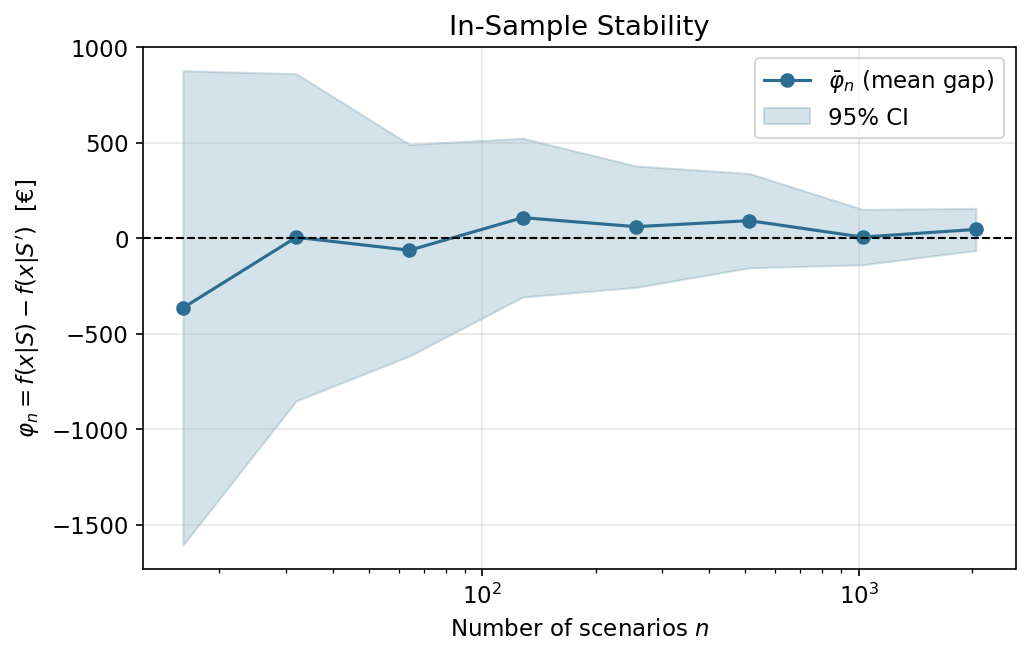

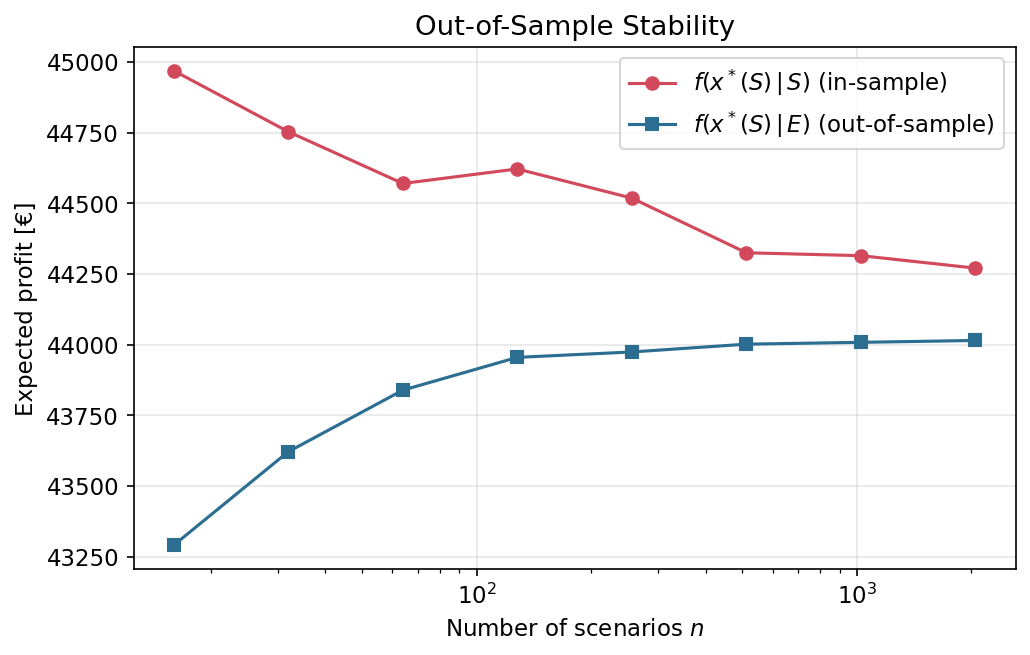

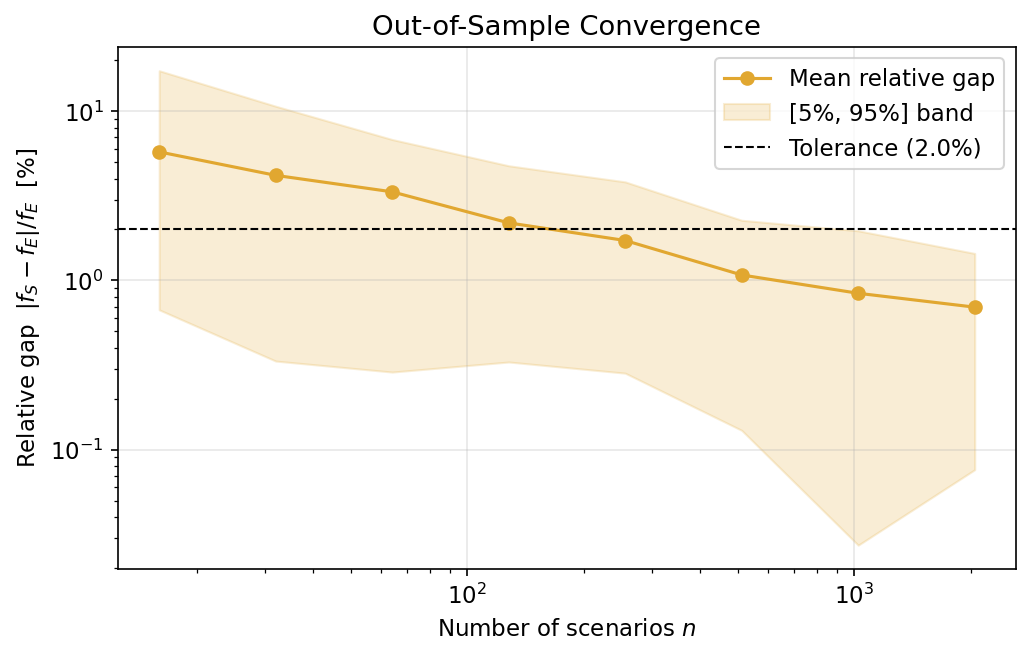

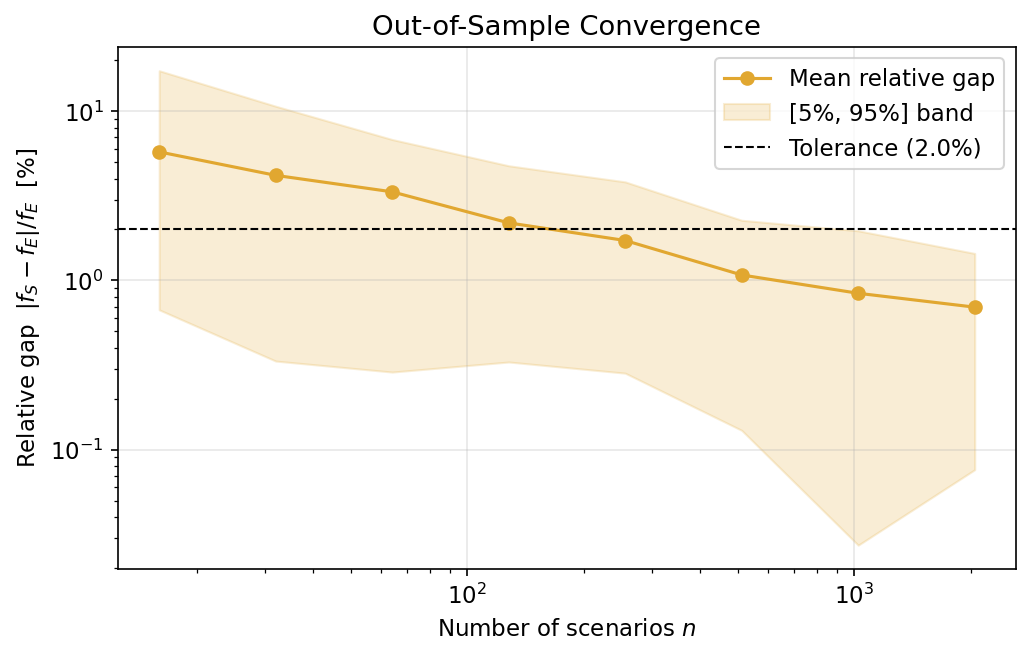

In [10]:
# ===================================================================================================================================================
# ==================================================================== Q1: STABILITY TEST ===========================================================
# ===================================================================================================================================================

# Scenario cardinalities (N)  to test
test_values = np.array([16, 32, 64, 128, 256, 512, 1024, 2048])

# Simulation parameters
N_pairs = 50 # Number of (S, S') pairs for In-Sample
N_runs = 50 # Number of x* evaluations for Out-of-Sample
E_big = 5000 # Size of the True Future matrix (Out-of-Sample)
confidence_level = 0.95
SEED = 357948 # Seed
TOLERANCE = 0.02 # Acceptable optimality gap for Out-of-Sample, percentage variation wrt objective function evaluated with E_big 

# In-Sample Results
n_stable_IS, results_IS = in_sample_stability(N_pairs=N_pairs, cardinality_scenarios=test_values, SEED=SEED, I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, mean=mean, var=var, confidence_level=confidence_level)
# Out-of-Sample Results
n_stable_OOS, results_OS = out_of_sample_stability(S_cardinality=test_values, N_runs=N_runs, I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, n_products=J, mean=mean, var=var, SEED=SEED, E_num_scenarios=E_big, tol=TOLERANCE)

#plots
plot_in_sample_stability(results_IS)
plot_out_of_sample_objectives(results_OS)
plot_relative_gap(results_OS, tol=TOLERANCE)


# ii)  calcolare e interpretare il VSS e l’EVPI

In [11]:
# ===================================================================================================================================================
# ==================================================================== Q2: VSS & EVPI ===============================================================
# ===================================================================================================================================================
WS, RP, RP_x, EEV, EVPI, VSS = compute_VSS_EVPI_metrics(I=I, J=J, M=M, C=C, P=P, L=L, T=T, G=G, mean=mean, var=var, SEED=SEED, N_stable=1024)


--- Stochastic Metrics Evaluation (N=1024) ---
Wait-and-See (WS):                € 54,205.55
Recourse Problem (RP):            € 44,801.03
Exp. Result of Exp. Value (EEV):  € 43,878.50
----------------------------------------------
EVPI (WS - RP):                   €  9,404.52
VSS  (RP - EEV):                  €    922.52
----------------------------------------------


# iii) Robustezza del modello

δ=-30% | μ-shift: €-34,571.67 (-77.17%) | σ²-shift: €+3,180.73 (+7.10%)
δ=-20% | μ-shift: €-18,889.32 (-42.16%) | σ²-shift: €+939.62 (+2.10%)
δ=-10% | μ-shift: €-8,817.48 (-19.68%) | σ²-shift: €+951.55 (+2.12%)
δ=+0% | μ-shift: €-110.70 (-0.25%) | σ²-shift: €-214.61 (-0.48%)
δ=+10% | μ-shift: €+4,457.74 (+9.95%) | σ²-shift: €-2,074.96 (-4.63%)
δ=+20% | μ-shift: €+7,417.84 (+16.56%) | σ²-shift: €-2,052.64 (-4.58%)
δ=+30% | μ-shift: €+9,089.88 (+20.29%) | σ²-shift: €-2,690.61 (-6.01%)


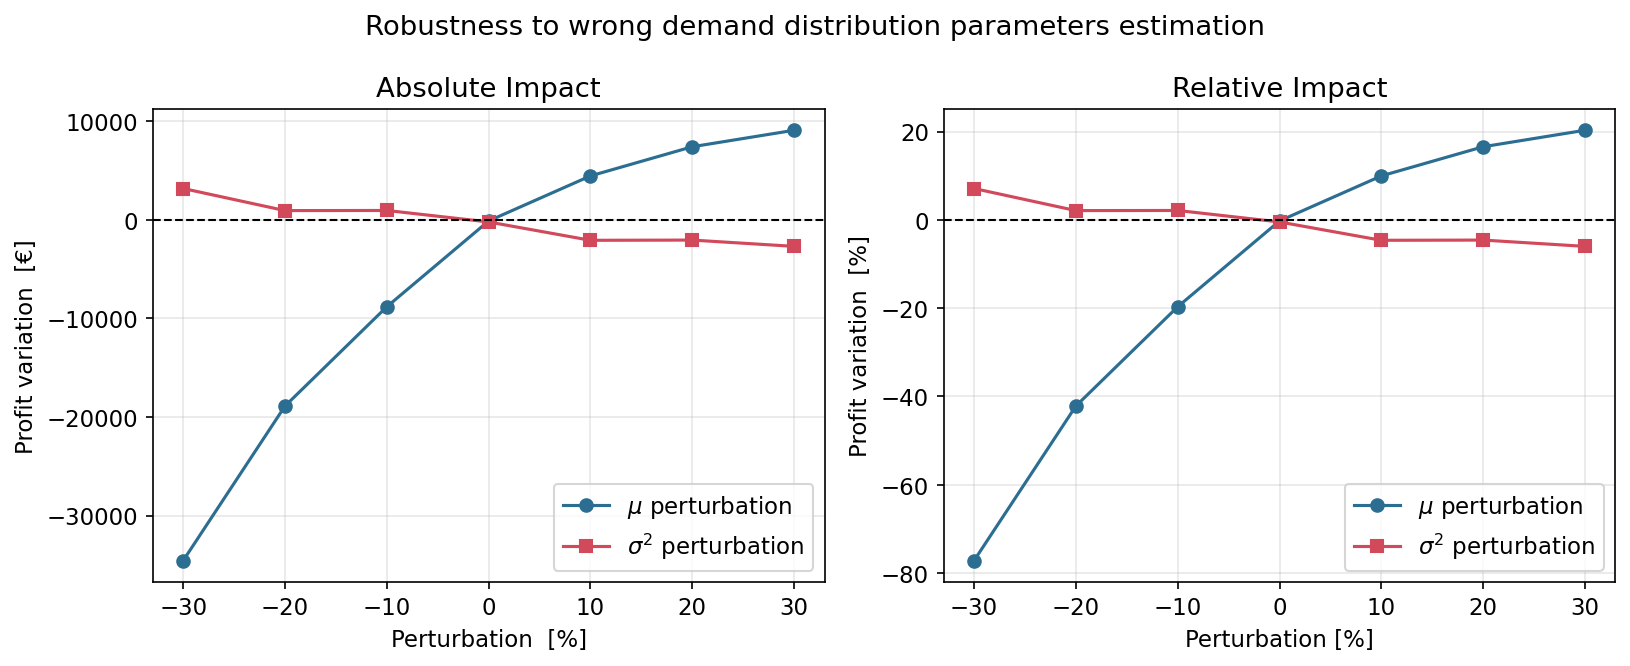

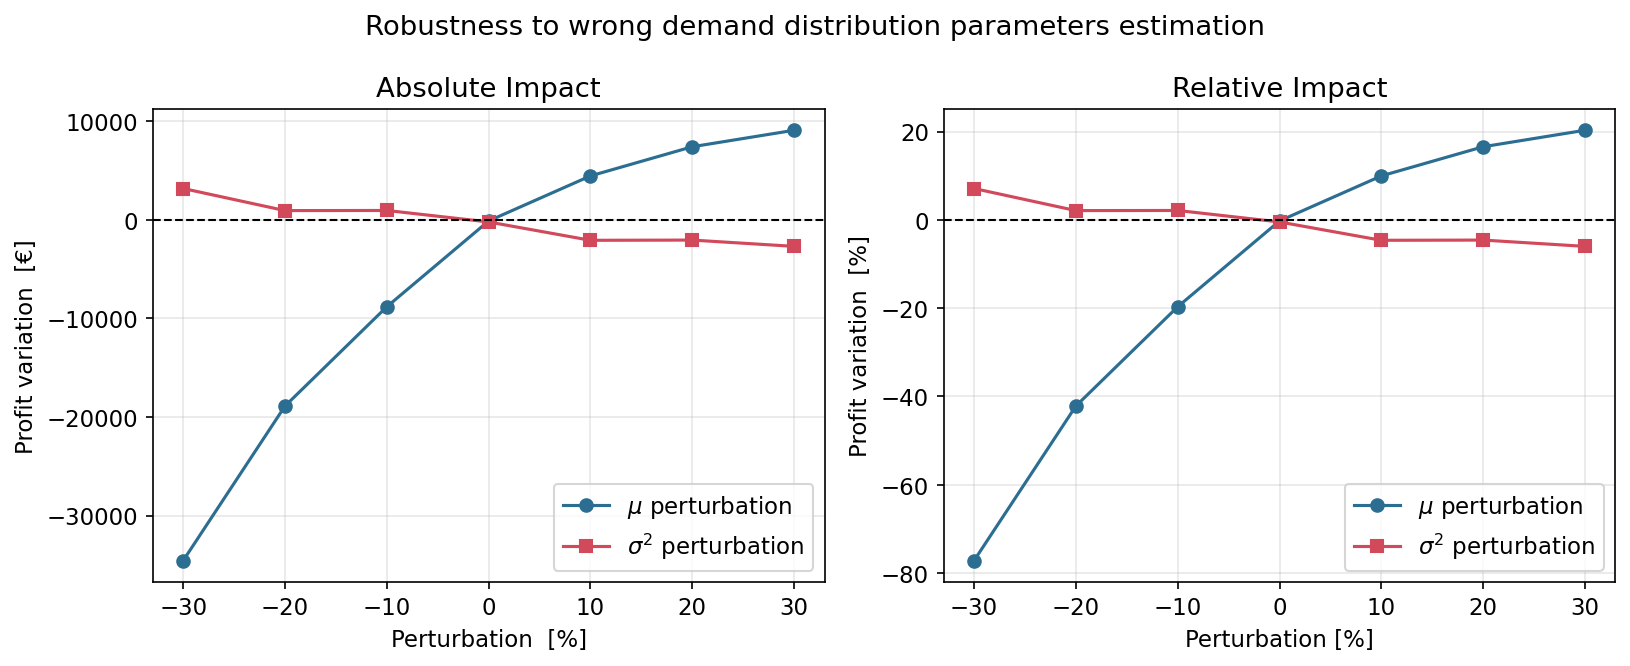

In [12]:
# ===================================================================================================================================================
# ================================================================ Q3: PARAMETERS ERROR ===========================================================
# ===================================================================================================================================================
deltas = np.array([-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3])

results_robust_params = robustness_parameter_perturbation(
    x_star=RP_x, mean=mean, var=var, RP_obj=RP,
    I=I, J=J, C=C, P=P, G=G, deltas=deltas, SEED=SEED, N_eval=1024
)
plot_robustness_parameters(results_robust_params)